# Nobel-Announcement-Drift — do sectors rally after the Nobel Prizes? 🏅
### When Medicine, Physics and Chemistry are announced each October, do pharma and tech drift?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

Every October, Stockholm reads out the Nobel Prizes. There's a bit of market folklore that says the *related* sectors should get a bump from all the attention: pharma and biotech after the **Medicine** prize, tech and semiconductors after **Physics** and **Chemistry**. The idea is that headlines → attention → buying → **drift** in the days that follow.

So we test it the clean way: take the health ETFs (XLV, IBB) and the tech/chip ETFs (XLK, SMH), line up **24 years** of announcement dates, and measure how each sector moved *relative to the market* in the 10 days after its prize.

> 📓 **This is the plain-language layer.** Want the *t*-stats, the placebo test and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from nobel_announcement_drift import data, strategy as st

H = 10

def load_real():
    """Cache-first real return panel + events (empty offline)."""
    px = data.fetch_prices(fetch=False)
    if px.empty:
        return None, None
    return st.daily_returns(px), data.nobel_events()

RETS, EVENTS = load_real()
HAVE_REAL = RETS is not None
print("real Nobel tape present:", HAVE_REAL,
      "" if not HAVE_REAL else f"({len(EVENTS)} announcements, {EVENTS.year.min()}-{EVENTS.year.max()})")


real Nobel tape present: True (72 announcements, 2001-2024)


## The answer first 🎯

| Question | Answer |
|---|---|
| Did the related sectors drift *up* after their prize? | **No.** Across 144 prize→sector events the average 10-day move (vs the market) was **-0.33%** — slightly *negative*. |
| Is that just an unlucky sample? | **No** — a random week in the *same* October beat it 98% of the time. Random October drifted **+0.14%**; Nobel weeks did worse. |
| Did *any* sector react? | The one clear move was **pharma after Medicine — down** (-0.94%, *t* -2.33). That's the opposite of the story. |
| Could you trade it? | **No.** It loses before costs, at every horizon, and the sign even flips between the early and late years. |

> A Nobel prize honours research done *decades* ago. It's a wonderful headline — but it isn't news about next quarter's earnings, so there's no reason for the stock of a whole sector to drift. And it doesn't.

## 1 · The claim

> *"When the Nobel science prizes are announced, the related sectors catch a news-attention bid and drift — pharma after Medicine, tech/semis after Physics & Chemistry."*

It's **folklore**, not a textbook anomaly — the sort of thing you hear on financial Twitter every October. The mechanism would be *attention*: a flood of headlines about a scientific field pulls retail eyeballs (and dollars) toward the obviously-related stocks. Attention *can* move prices short-term — the question is whether a Nobel announcement is a big enough, specific enough shock to leave a footprint you could trade.

## 2 · So what?

If it were real, it'd be a free calendar trade: you know the announcement dates *years* in advance, so you could just buy the sector the morning after. The desk has looked at plenty of *real* announcement drifts — after [earnings](../../363-pead-drift/), after [product keynotes](../../299-keynote-drift/), around the [Fed](../../517-pre-fomc-drift/). Those carry a genuine *surprise*. A Nobel prize doesn't. So this is a clean test of whether **pure attention, with no cash-flow news, drifts a sector**.

## 3 · How would we even know?

1. **The dates.** The three science prizes are announced on the Mon/Tue/Wed of the first full week of October. We hardcode 24 years of them (2001-2024).
2. **The map.** Medicine → health ETFs (XLV, IBB); Physics & Chemistry → tech/chips (XLK, SMH).
3. **The measure.** For each event, how did the sector move over the next 10 trading days — *minus* how the whole market (SPY) moved? (A prize that happened to fall in a great week for stocks isn't a Nobel effect.) That market-adjusted move is the **abnormal return**.
4. **The sanity check.** Compare it to a *random* week in the same October. If Nobel weeks aren't special, random October weeks should look just as good.

*Timing:* the announcement is public the instant it's read out and is scheduled weeks ahead, so we enter at the close of the first trading day on/after it and hold 10 days — no peeking at the future.

## 4 · The teardown — let's actually look

**Which prizes moved their sector, and in which direction?** (10-day market-adjusted return.)

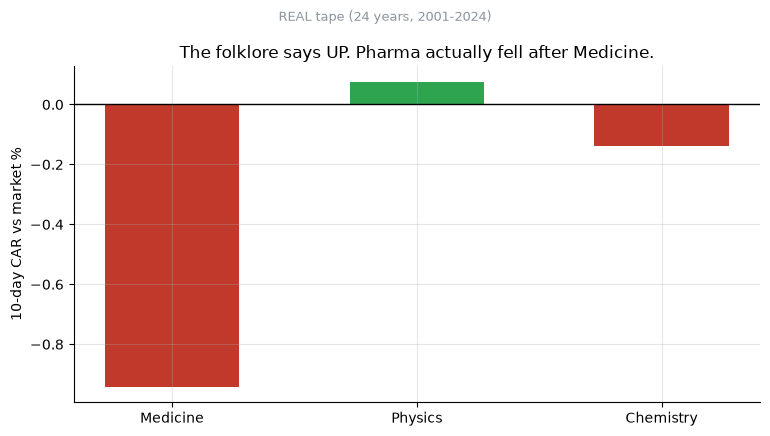

Medicine   10-day CAR -0.94%
Physics    10-day CAR +0.08%
Chemistry  10-day CAR -0.14%


In [2]:
labs = ['Medicine', 'Physics', 'Chemistry']
if HAVE_REAL:
    tab = st.event_car_table(RETS, EVENTS, data.PRIZE_SECTOR, data.BENCHMARK, horizon=H)
    vals = [st.car_summary(tab[tab.prize==p])['mean_car']*100 for p in ['medicine','physics','chemistry']]
    banner = 'REAL tape (24 years, 2001-2024)'
else:
    vals = [-0.94, 0.08, -0.14]
    banner = 'frozen real numbers (offline)'
fig, ax = plt.subplots(figsize=(7.8, 4.4))
cols = [GREEN if v>0 else RED for v in vals]
ax.bar(labs, vals, color=cols, width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('10-day CAR vs market %')
ax.set_title('The folklore says UP. Pharma actually fell after Medicine.')
fig.suptitle(banner, fontsize=9, color=GREY); plt.tight_layout(); plt.show()
for l,v in zip(labs, vals): print(f'{l:10s} 10-day CAR {v:+.2f}%')

There it is: no positive drift anywhere. **Medicine** — the prize the folklore is most confident about — moved health stocks **down** (-0.94%). Physics and Chemistry barely moved tech at all. The attention bid just isn't there.

**Are Nobel weeks even special?** Compare the actual Nobel week to a *random* week in the same October, thousands of times over:

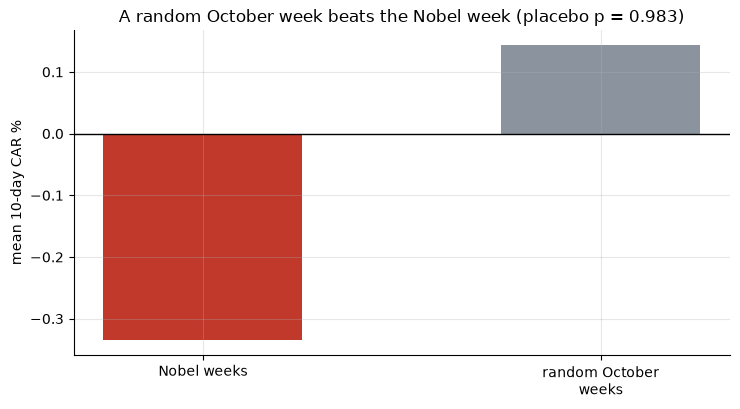

Nobel weeks -0.33%  vs  random October +0.14%  ->  placebo p 0.983


In [3]:
obs, pmean, pval = -0.33, 0.14, 0.984
if HAVE_REAL:
    pb = st.placebo_pvalue(RETS, EVENTS, data.PRIZE_SECTOR, data.BENCHMARK, horizon=H, n_draws=1500, seed=546)
    obs, pmean, pval = pb['obs']*100, pb['placebo_mean']*100, pb['p_value']
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.bar(['Nobel weeks','random October\nweeks'], [obs, pmean], color=[RED, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('mean 10-day CAR %')
ax.set_title(f'A random October week beats the Nobel week (placebo p = {pval:.3f})')
plt.tight_layout(); plt.show()
print(f'Nobel weeks {obs:+.2f}%  vs  random October {pmean:+.2f}%  ->  placebo p {pval:.3f}')

A random week in the same month did **better** than the actual Nobel week (98% of random draws beat it). So there is no announcement effect at all — if anything Nobel weeks are slightly *worse* than an ordinary October week.

## 5 · The verdict

- **Signal — None.** The average post-Nobel sector move is **-0.33%** (*t* -1.36) — insignificant and the wrong sign, and a random October week beats it.
- **Tradability — Mirage.** It loses before costs, at every holding length, and the sign flips between the early and late years. Nothing to trade.

## 6 · Could you actually trade it?

No. Even ignoring the wrong sign, you'd be buying a broad sector ETF on the strength of a headline about research from the 1980s. There's no earnings surprise, no guidance change, no cash-flow news — just a lovely story. Markets price *cash flows and surprises*, and a Nobel prize is neither.

## 7 · Going further 🚪

- **The real drifts.** [363 PEAD](../../363-pead-drift/), [299 Keynote-Drift](../../299-keynote-drift/) and [515 Earnings-Announcement-Premium](../../515-earnings-announcement-premium/) are announcements that carry a *surprise* — that's where drift actually lives.
- **Other rituals.** [158 Super-Bowl](../../158-super-bowl/) and [95 Holiday-Cheer](../../95-holiday-cheer/) test other calendar folklore.

*Think there's a same-day pop we averaged away? Fork this, measure the announcement-day return itself (not the 10-day drift), and show it clears t = 2 the right way.*